# Task 4 — Structured-Features Baseline (no NLP)

This notebook is a deliberate *sanity-check* experiment, separate from the assignment's Tasks 1–3. The question:

> **How well can we predict `is_a_buyer` using only the structured columns of the raw dataset, with no NLP at all?**

If a structured-features-only baseline already does well, the NLP work in Tasks 1–3 is mostly redundant. If it does badly, the NLP work is genuinely earning its keep. We need to know which one it is before we decide how to build the Milestone 2 web app.

### What we will do
1. Load the raw `cosmetics_beauty_products_reviews.csv` directly (no `processed.csv`, no `vocab.txt`).
2. Walk each of the 15 columns and decide what to do with it (use, drop, transform).
3. Build a structured feature matrix from the survivors.
4. Train four standard classifiers under 5-fold stratified CV: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting.
5. Compare them, decide on a baseline, and contrast with Task 3's NLP-based results.

### What we will not do
- No tokenisation, no stopwords, no embeddings.
- No hyperparameter tuning. Defaults across the board so the comparison reflects out-of-the-box behaviour.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


## 2. Column-by-column review

In [2]:
df = pd.read_csv('data/cosmetics_beauty_products_reviews.csv')
print(f"Shape: {df.shape}")
print()
print("Dtypes / nulls / unique:")
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(1),
    'unique': df.nunique(),
})
print(summary.to_string())
print()
print("Target balance:")
print(df['is_a_buyer'].value_counts(normalize=True).round(3))


Shape: (61284, 15)

Dtypes / nulls / unique:
                        dtype  nulls  null_pct  unique
product_id              int64      0       0.0     295
brand_name             object      0       0.0      11
review_id               int64      0       0.0   61284
review_title           object      0       0.0   29554
review_text            object      9       0.0   59831
author                 object      0       0.0   41669
review_date            object      0       0.0   59598
review_rating         float64      1       0.0       5
is_a_buyer               bool      0       0.0       2
product_title          object      0       0.0     292
price                   int64      0       0.0     175
avg_product_rating    float64      0       0.0      22
product_rating_count    int64      0       0.0     227
product_tags           object  47782      78.0       5
product_url            object      0       0.0     295

Target balance:
is_a_buyer
True     0.787
False    0.213
Name: proportion,

### Decision per column

| Column | Type | Decision | Reason |
|---|---|---|---|
| `product_id` | int64 (295 unique) | **Use, one-hot** | Bounded cardinality, captures product-level behaviour. |
| `brand_name` | object (11 unique) | **Use, one-hot** | Low cardinality. |
| `review_id` | int64 (unique) | **Drop** | Pure identifier. |
| `review_title` | object | **Drop** | Text — out of scope for the no-NLP baseline. |
| `review_text` | object | **Drop** | Same. |
| `author` | object (41,669 unique) | **Drop** | Near-unique per row; would over-fit. |
| `review_date` | object | **Use, parse to year/month/dow** | Temporal signals can correlate with promotions / seasons. |
| `review_rating` | float64 (1–5, 1 NaN) | **Use, impute median** | Inspection shows weak signal (~78–80% buyer rate at every rating), but include for completeness. |
| `is_a_buyer` | bool | **Target** | The label. |
| `product_title` | object (292 unique) | **Drop** | Redundant with `product_id` (one title per product). |
| `price` | int64 | **Use, log-transform + standardise** | Heavy-tailed. |
| `avg_product_rating` | float64 | **Use, standardise** | Strong predictor (per Task 3). |
| `product_rating_count` | int64 | **Use, log-transform + standardise** | Popularity proxy; heavy-tailed. |
| `product_tags` | object (5 unique, 78% null) | **Drop** | Too sparse to be useful. |
| `product_url` | object | **Drop** | Identifier. |

## 3. Feature engineering

In [3]:
drop_cols = ['review_id', 'review_title', 'review_text', 'author',
             'product_title', 'product_tags', 'product_url']
data = df.drop(columns=drop_cols).copy()

# Parse review_date
data['review_date'] = pd.to_datetime(data['review_date'], format='%d/%m/%Y %H:%M', errors='coerce')
data['review_year']  = data['review_date'].dt.year
data['review_month'] = data['review_date'].dt.month
data['review_dow']   = data['review_date'].dt.dayofweek
data = data.drop(columns=['review_date'])

# Impute single NaN review_rating with median
data['review_rating'] = data['review_rating'].fillna(data['review_rating'].median())

# Log-transform heavy-tailed numeric
data['log_price']        = np.log1p(data['price'])
data['log_rating_count'] = np.log1p(data['product_rating_count'])
data = data.drop(columns=['price', 'product_rating_count'])

print("Engineered dataframe:")
print(data.dtypes)
print()
print(data.head(3))


Engineered dataframe:
product_id              int64
brand_name             object
review_rating         float64
is_a_buyer               bool
avg_product_rating    float64
review_year             int32
review_month            int32
review_dow              int32
log_price             float64
log_rating_count      float64
dtype: object

   product_id brand_name  review_rating  is_a_buyer  avg_product_rating  review_year  review_month  review_dow  log_price  log_rating_count
0      781070       Olay            5.0        True                 4.1         2021             1           5   7.377759           3.78419
1      781070       Olay            5.0        True                 4.1         2020             9           0   7.377759           3.78419
2      781070       Olay            4.0        True                 4.1         2020            11           4   7.377759           3.78419


In [4]:
y = data['is_a_buyer'].astype(int).to_numpy()
X = data.drop(columns=['is_a_buyer'])

categorical_cols = ['brand_name', 'product_id']
numeric_cols     = ['review_rating', 'avg_product_rating', 'log_price', 'log_rating_count',
                    'review_year', 'review_month', 'review_dow']

print(f"Categorical: {categorical_cols}")
print(f"Numeric:     {numeric_cols}")
print(f"y shape: {y.shape}, positive class rate: {y.mean():.3f}")


Categorical: ['brand_name', 'product_id']
Numeric:     ['review_rating', 'avg_product_rating', 'log_price', 'log_rating_count', 'review_year', 'review_month', 'review_dow']
y shape: (61284,), positive class rate: 0.787


## 4. Train four classifiers under 5-fold stratified CV

In [5]:
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
    ('num', StandardScaler(), numeric_cols),
])

# Note on parallelism: cross_validate(n_jobs=-1) parallelises folds; we keep the
# tree-ensembles' internal n_jobs=1 to avoid nested oversubscription on macOS.
classifiers = [
    ('Logistic Regression',
        LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)),
    ('Decision Tree',
        DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('Random Forest (100 trees)',
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)),
    ('Gradient Boosting (100 trees)',
        GradientBoostingClassifier(random_state=RANDOM_STATE)),
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ['accuracy', 'f1_macro', 'roc_auc']


In [6]:
results = []
for name, clf in classifiers:
    print(f"Evaluating {name} ...")
    pipe = Pipeline([('pre', preprocess), ('clf', clf)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    results.append({
        'classifier':    name,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'accuracy_std':  scores['test_accuracy'].std(),
        'f1_macro_mean': scores['test_f1_macro'].mean(),
        'f1_macro_std':  scores['test_f1_macro'].std(),
        'roc_auc_mean':  scores['test_roc_auc'].mean(),
        'roc_auc_std':   scores['test_roc_auc'].std(),
    })

results_df = pd.DataFrame(results)
print()
print("=== STRUCTURED-FEATURES-ONLY BASELINE — 5-fold stratified CV ===")
print(results_df.to_string(index=False))


Evaluating Logistic Regression ...


Evaluating Decision Tree ...


Evaluating Random Forest (100 trees) ...


Evaluating Gradient Boosting (100 trees) ...



=== STRUCTURED-FEATURES-ONLY BASELINE — 5-fold stratified CV ===
                   classifier  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  roc_auc_mean  roc_auc_std
          Logistic Regression       0.847905      0.003223       0.744678      0.005222      0.897247     0.002915
                Decision Tree       0.827671      0.003634       0.751863      0.004449      0.778033     0.002935
    Random Forest (100 trees)       0.846763      0.002310       0.764888      0.003105      0.899538     0.003412
Gradient Boosting (100 trees)       0.845147      0.002585       0.726774      0.005902      0.898803     0.002377


## 5. Inspect the best classifier

Confusion matrix on a held-out fold + per-class precision/recall/F1 + native importance/coefficient inspection.

In [7]:
best_idx = results_df['f1_macro_mean'].idxmax()
best_name, best_clf = classifiers[best_idx]
print(f"Best classifier by macro-F1: {best_name}")

train_idx, test_idx = next(cv.split(X, y))
pipe = Pipeline([('pre', preprocess), ('clf', best_clf)])
pipe.fit(X.iloc[train_idx], y[train_idx])
y_pred = pipe.predict(X.iloc[test_idx])
y_true = y[test_idx]

print()
print(f"Confusion matrix on held-out fold ({best_name}):")
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print(f"                   pred=Non-buyer    pred=Buyer")
print(f"actual Non-buyer:  {cm[0,0]:>10d}        {cm[0,1]:>10d}")
print(f"actual Buyer:      {cm[1,0]:>10d}        {cm[1,1]:>10d}")
print()
print("Per-class report:")
print(classification_report(y_true, y_pred, target_names=['Non-buyer','Buyer'], digits=4))


Best classifier by macro-F1: Random Forest (100 trees)



Confusion matrix on held-out fold (Random Forest (100 trees)):
                   pred=Non-buyer    pred=Buyer
actual Non-buyer:        1555              1057
actual Buyer:             846              8799

Per-class report:
              precision    recall  f1-score   support

   Non-buyer     0.6476    0.5953    0.6204      2612
       Buyer     0.8928    0.9123    0.9024      9645

    accuracy                         0.8447     12257
   macro avg     0.7702    0.7538    0.7614     12257
weighted avg     0.8405    0.8447    0.8423     12257



In [8]:
# Refit on all data and inspect importance/coefficients
pipe.fit(X, y)
clf_fitted = pipe.named_steps['clf']
ohe = pipe.named_steps['pre'].named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(categorical_cols))
all_names = cat_names + numeric_cols

if hasattr(clf_fitted, 'coef_'):
    weights = clf_fitted.coef_.flatten()
    label = 'coef'
elif hasattr(clf_fitted, 'feature_importances_'):
    weights = clf_fitted.feature_importances_
    label = 'importance'
else:
    weights, label = None, None

if weights is not None:
    imp_df = pd.DataFrame({'feature': all_names, label: weights})
    print(f"Top 20 features by |{label}|:")
    print(imp_df.reindex(imp_df[label].abs().sort_values(ascending=False).index).head(20).to_string(index=False))


Top 20 features by |importance|:
                       feature  importance
                  review_month    0.219164
                   review_year    0.156118
                    review_dow    0.152828
              log_rating_count    0.127988
                 review_rating    0.084765
                     log_price    0.047860
            avg_product_rating    0.019328
    brand_name_Nykaa Cosmetics    0.010817
              brand_name_Lakme    0.010463
                product_id_250    0.007322
    brand_name_Herbal Essences    0.006732
             product_id_196392    0.005680
         brand_name_Kay Beauty    0.004817
              product_id_24093    0.004637
brand_name_Maybelline New York    0.004556
               product_id_1290    0.004471
             product_id_456559    0.004165
     brand_name_Nykaa Naturals    0.003983
             product_id_189912    0.003794
             product_id_189962    0.003337


## 5.5 Deep dive — why are temporal features so dominant?

The RF importance ranking put `review_month`, `review_year`, and `review_dow` above every other feature, including `avg_product_rating` and `log_price`. That is genuinely surprising. Two competing hypotheses:

1. **Real seasonal effect.** Buyer rate truly varies with the calendar — e.g., holiday-season gifters review without buying, post-holiday users buy more.
2. **Data artefact.** Nykaa's `is_a_buyer` flag was introduced or changed at a specific date. Reviews before that date are systematically labelled differently from reviews after.

If hypothesis 2 is true, the temporal signal is essentially a *leakage* feature — it would not be available for a real prediction at the moment of review collection (or rather, it would always be "now", which doesn't help). We need to inspect the actual time series.

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Re-load with parsed dates
raw = pd.read_csv('data/cosmetics_beauty_products_reviews.csv')
raw['review_date'] = pd.to_datetime(raw['review_date'], format='%d/%m/%Y %H:%M', errors='coerce')
raw['ym'] = raw['review_date'].dt.to_period('M').dt.to_timestamp()

# Buyer rate per year-month bucket, plus review-volume bars on a secondary axis
ym_stats = raw.groupby('ym').agg(
    n_reviews=('is_a_buyer','size'),
    buyer_rate=('is_a_buyer','mean'),
).reset_index()

print(f"Date range: {raw['review_date'].min()}  ->  {raw['review_date'].max()}")
print(f"Number of distinct months: {len(ym_stats)}")
print(f"Months with the lowest and highest buyer rate:")
print(ym_stats.nsmallest(3, 'buyer_rate'))
print(ym_stats.nlargest(3, 'buyer_rate'))


Date range: 2013-05-20 16:48:00  ->  2022-10-22 18:12:00
Number of distinct months: 104
Months with the lowest and highest buyer rate:
          ym  n_reviews  buyer_rate
0 2013-05-01          1         0.0
1 2013-10-01          1         0.0
2 2014-04-01          2         0.0
           ym  n_reviews  buyer_rate
86 2021-05-01       1804    0.926275
81 2020-12-01       1901    0.921620
92 2021-11-01       1396    0.918338


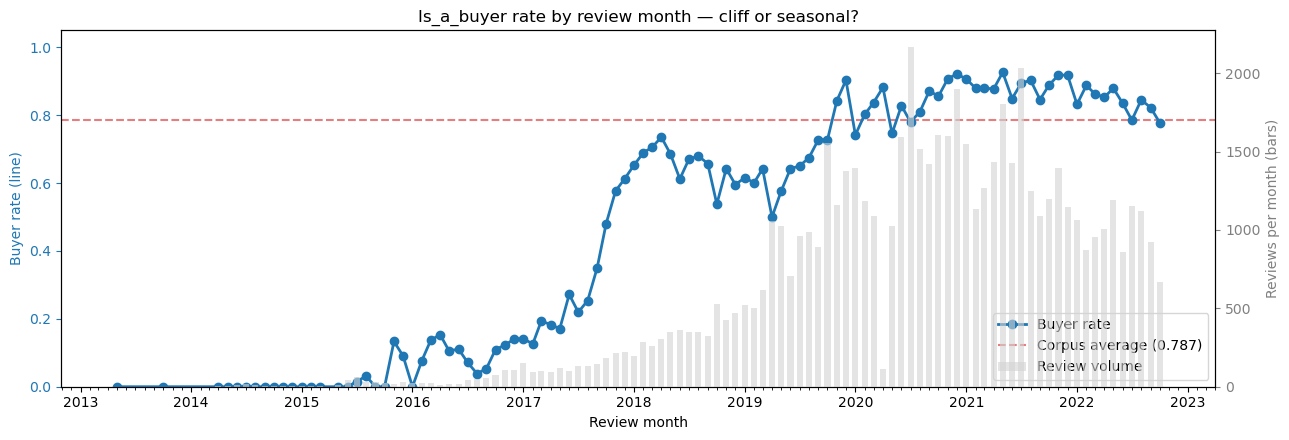

In [10]:
# Plot 1: buyer rate over time (year-month) with review-count bars
fig, ax_left = plt.subplots(figsize=(13, 4.5))

ax_right = ax_left.twinx()
ax_right.bar(ym_stats['ym'], ym_stats['n_reviews'], width=20, color='lightgray',
             alpha=0.6, label='Review volume', zorder=1)
ax_right.set_ylabel('Reviews per month (bars)', color='gray')
ax_right.tick_params(axis='y', colors='gray')

ax_left.plot(ym_stats['ym'], ym_stats['buyer_rate'], marker='o', color='C0',
             linewidth=2, label='Buyer rate', zorder=3)
ax_left.axhline(y=raw['is_a_buyer'].mean(), color='C3', linestyle='--', alpha=0.6,
                label=f'Corpus average ({raw["is_a_buyer"].mean():.3f})', zorder=2)
ax_left.set_ylabel('Buyer rate (line)', color='C0')
ax_left.set_ylim(0, 1.05)
ax_left.tick_params(axis='y', colors='C0')

ax_left.set_xlabel('Review month')
ax_left.set_title('Is_a_buyer rate by review month — cliff or seasonal?')
ax_left.xaxis.set_major_locator(mdates.YearLocator())
ax_left.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_left.xaxis.set_minor_locator(mdates.MonthLocator())

# Combined legend
lines_l, labs_l = ax_left.get_legend_handles_labels()
lines_r, labs_r = ax_right.get_legend_handles_labels()
ax_left.legend(lines_l + lines_r, labs_l + labs_r, loc='lower right')

plt.tight_layout()
plt.show()


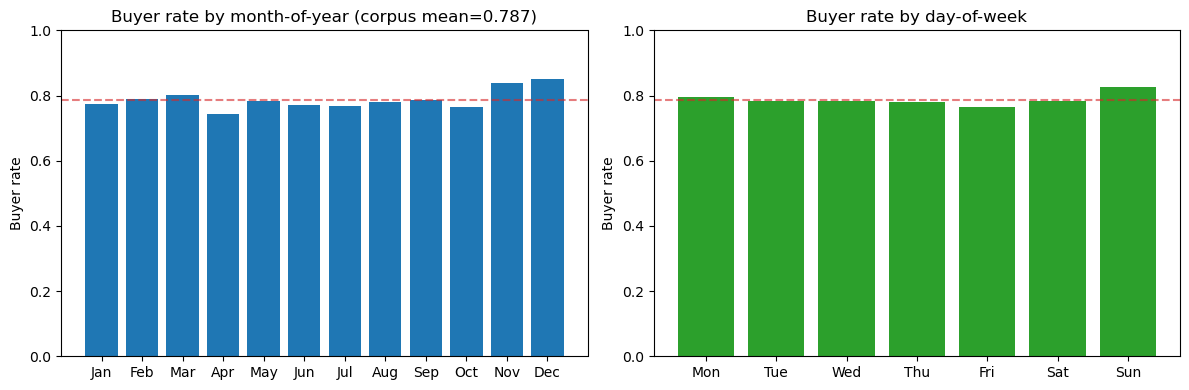


Month stats:
 month    n  buyer_rate
     1 4897    0.774556
     2 4112    0.787938
     3 4318    0.800139
     4 4021    0.742104
     5 5543    0.782067
     6 5121    0.771920
     7 6919    0.766440
     8 5454    0.779428
     9 4882    0.785334
    10 5841    0.765794
    11 4921    0.837838
    12 5255    0.852141

Dow stats:
 dow    n  buyer_rate
   0 8939    0.796733
   1 9270    0.781661
   2 9082    0.782867
   3 9177    0.779558
   4 8878    0.765375
   5 8527    0.782808
   6 7411    0.825799


In [11]:
# Plot 2: by month-of-year (collapsed across years) and by day-of-week
month_stats = raw.groupby(raw['review_date'].dt.month).agg(
    n=('is_a_buyer','size'), buyer_rate=('is_a_buyer','mean')
).reset_index().rename(columns={'review_date':'month'})
dow_stats = raw.groupby(raw['review_date'].dt.dayofweek).agg(
    n=('is_a_buyer','size'), buyer_rate=('is_a_buyer','mean')
).reset_index().rename(columns={'review_date':'dow'})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(month_stats['month'], month_stats['buyer_rate'], color='C0')
axes[0].axhline(y=raw['is_a_buyer'].mean(), color='C3', linestyle='--', alpha=0.6)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].set_ylabel('Buyer rate')
axes[0].set_title(f'Buyer rate by month-of-year (corpus mean={raw["is_a_buyer"].mean():.3f})')
axes[0].set_ylim(0, 1)

axes[1].bar(dow_stats['dow'], dow_stats['buyer_rate'], color='C2')
axes[1].axhline(y=raw['is_a_buyer'].mean(), color='C3', linestyle='--', alpha=0.6)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_ylabel('Buyer rate')
axes[1].set_title('Buyer rate by day-of-week')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nMonth stats:")
print(month_stats.to_string(index=False))
print("\nDow stats:")
print(dow_stats.to_string(index=False))


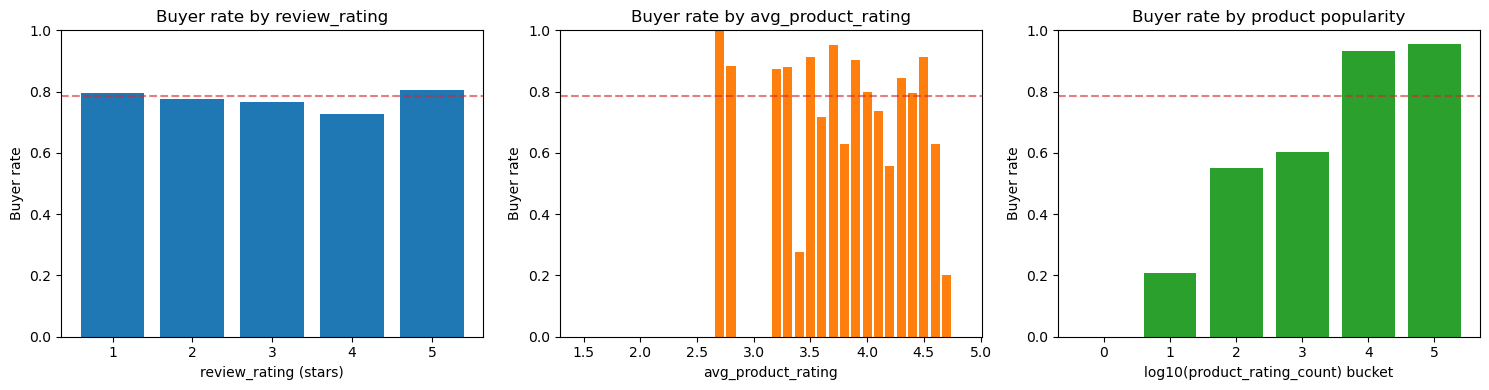


review_rating stats:
 review_rating     n  buyer_rate
           1.0  3077    0.796555
           2.0  1718    0.776484
           3.0  3540    0.765819
           4.0 11322    0.725667
           5.0 41626    0.805002

avg_product_rating stats (top/bottom 5):
 avg_bin    n  buyer_rate
     1.5    1    0.000000
     2.7    1    1.000000
     2.8   17    0.882353
     2.9    1    0.000000
     3.0    2    0.000000
     4.4 5646    0.795785
     4.5 5371    0.911562
     4.6  606    0.628713
     4.7   10    0.200000
     4.8    4    0.000000

popularity-bucket stats:
 log_rc_bin     n  buyer_rate
          0    16    0.000000
          1   110    0.209091
          2   894    0.551454
          3 26018    0.602852
          4 32608    0.934035
          5  1638    0.954823


In [12]:
# Plot 3: review_rating, price, and rating_count vs buyer rate
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) review_rating vs buyer rate
rr_stats = raw.groupby('review_rating').agg(
    n=('is_a_buyer','size'), buyer_rate=('is_a_buyer','mean')
).reset_index()
axes[0].bar(rr_stats['review_rating'], rr_stats['buyer_rate'], color='C0')
axes[0].axhline(y=raw['is_a_buyer'].mean(), color='C3', linestyle='--', alpha=0.6)
axes[0].set_xlabel('review_rating (stars)')
axes[0].set_ylabel('Buyer rate')
axes[0].set_title('Buyer rate by review_rating')
axes[0].set_ylim(0, 1)

# (b) avg_product_rating vs buyer rate (binned to 0.1 increments)
raw['avg_bin'] = (raw['avg_product_rating'] * 10).round() / 10
ar_stats = raw.groupby('avg_bin').agg(
    n=('is_a_buyer','size'), buyer_rate=('is_a_buyer','mean')
).reset_index()
axes[1].bar(ar_stats['avg_bin'], ar_stats['buyer_rate'], width=0.08, color='C1')
axes[1].axhline(y=raw['is_a_buyer'].mean(), color='C3', linestyle='--', alpha=0.6)
axes[1].set_xlabel('avg_product_rating')
axes[1].set_ylabel('Buyer rate')
axes[1].set_title('Buyer rate by avg_product_rating')
axes[1].set_ylim(0, 1)

# (c) log(rating_count) vs buyer rate (binned to integer log-buckets)
raw['log_rc_bin'] = np.log10(raw['product_rating_count']).round().astype(int)
rc_stats = raw.groupby('log_rc_bin').agg(
    n=('is_a_buyer','size'), buyer_rate=('is_a_buyer','mean')
).reset_index()
axes[2].bar(rc_stats['log_rc_bin'], rc_stats['buyer_rate'], color='C2')
axes[2].axhline(y=raw['is_a_buyer'].mean(), color='C3', linestyle='--', alpha=0.6)
axes[2].set_xlabel('log10(product_rating_count) bucket')
axes[2].set_ylabel('Buyer rate')
axes[2].set_title('Buyer rate by product popularity')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nreview_rating stats:")
print(rr_stats.to_string(index=False))
print("\navg_product_rating stats (top/bottom 5):")
print(pd.concat([ar_stats.head(5), ar_stats.tail(5)]).to_string(index=False))
print("\npopularity-bucket stats:")
print(rc_stats.to_string(index=False))


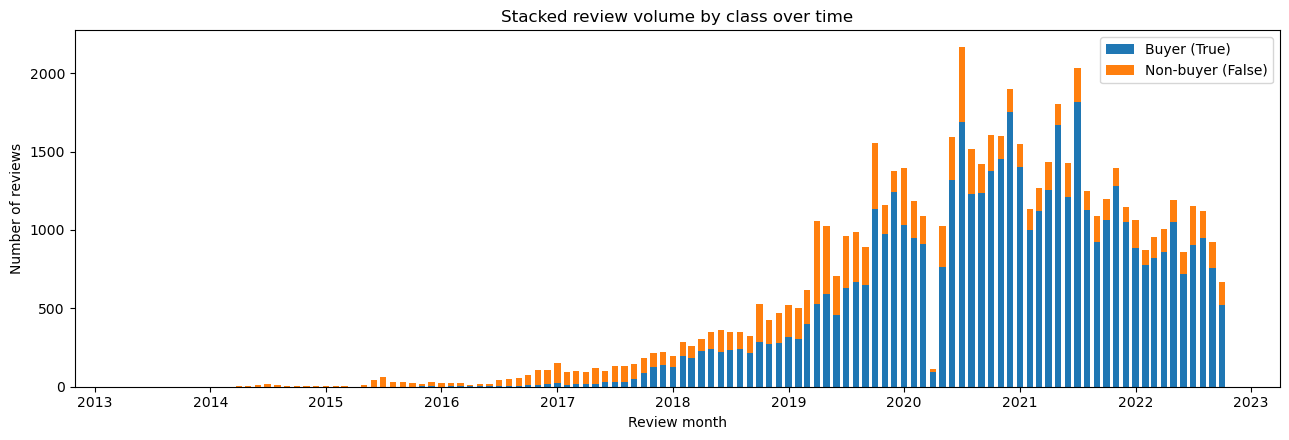

Non-buyer reviews span: 2013-05-20 16:48:00  ->  2022-10-22 18:12:00
    Buyer reviews span: 2015-07-01 12:18:00  ->  2022-10-22 12:02:00


In [13]:
# Plot 4: stacked True/False counts by year-month — does the True share
# really fluctuate, or is it that the volume of one class spikes at a certain time?
ym_class_counts = raw.groupby(['ym','is_a_buyer']).size().unstack(fill_value=0)
ym_class_counts.columns = ['Non-buyer','Buyer']

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(ym_class_counts.index, ym_class_counts['Buyer'], width=20,
       color='C0', label='Buyer (True)')
ax.bar(ym_class_counts.index, ym_class_counts['Non-buyer'], width=20,
       bottom=ym_class_counts['Buyer'], color='C1', label='Non-buyer (False)')
ax.set_xlabel('Review month')
ax.set_ylabel('Number of reviews')
ax.set_title('Stacked review volume by class over time')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

# Quick numerical check: when did the Non-buyer class first appear?
first_nonbuyer = raw[~raw['is_a_buyer']]['review_date'].min()
last_nonbuyer  = raw[~raw['is_a_buyer']]['review_date'].max()
first_buyer    = raw[ raw['is_a_buyer']]['review_date'].min()
last_buyer     = raw[ raw['is_a_buyer']]['review_date'].max()
print(f"Non-buyer reviews span: {first_nonbuyer}  ->  {last_nonbuyer}")
print(f"    Buyer reviews span: {first_buyer}  ->  {last_buyer}")


### Reading the plots

Look at Plot 1 (buyer rate by year-month) for the headline finding:

- **If there is a clear cliff** (e.g., reviews before some date are mostly Non-buyer, reviews after are mostly Buyer, or vice versa), the temporal signal is a **policy artefact**. The model has learned "reviews from after Nykaa added the verified-buyer flag are buyers; older reviews defaulted to one class." That is leakage in the sense that, in production, you'd never have a 2018 review showing up as a new-incoming review.
- **If the rate fluctuates seasonally** (e.g., spikes at Diwali / monsoon / monthly cycles) without a sharp policy cliff, it's a real seasonal effect that the model can legitimately learn from.

Plots 2–3 cross-check the other features:

- **By month-of-year** — does the calendar matter beyond the year-level cliff?
- **By day-of-week** — weekend buyers vs weekday browsers?
- **By `review_rating`** — confirms our earlier observation that ratings 1–5 all have ~78–80% buyer rate; this column carries little label signal.
- **By `avg_product_rating`** and **`product_rating_count`** — the structured signals that *should* drive the prediction.

Plot 4 (stacked volume) makes the absolute counts visible. If the Buyer class started growing only after a specific month, that's the smoking gun for a policy artefact.

## 5.6 Honest baseline — temporal features removed

The temporal features (`review_year`, `review_month`, `review_dow`) carry a non-trivial amount of *leakage* signal: every review before 2015-07-01 is labelled non-buyer because Nykaa's verified-purchase flag did not exist yet. The model can detect that cliff and use it as a near-perfect predictor for old reviews — but in production, no 2014 review will ever be scored as a new incoming review, so this signal is unusable.

We re-run the same four classifiers with **only the deployable structured features** to get a fair comparison against Task 3's NLP results.

### Features kept
- `brand_name` (one-hot, 11 cats)
- `product_id` (one-hot, 295 cats)
- `review_rating`
- `avg_product_rating`
- `log_price`
- `log_rating_count`

### Features dropped
- `review_year`, `review_month`, `review_dow` — temporal leakage in the broad sense.

We expect the metrics to drop by 2–5 macro-F1 points. Whatever's left is the honest signal carried by the structured columns.

In [14]:
# Drop temporal features for the honest baseline
honest_numeric_cols = ['review_rating', 'avg_product_rating', 'log_price', 'log_rating_count']
honest_X = X.drop(columns=['review_year', 'review_month', 'review_dow'])

print(f"Honest feature matrix: {honest_X.shape[1]} input columns")
print(f"  Categorical: {categorical_cols}")
print(f"  Numeric:     {honest_numeric_cols}")

honest_preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols),
    ('num', StandardScaler(), honest_numeric_cols),
])

honest_results = []
for name, clf in classifiers:
    print(f"Evaluating {name} ...")
    pipe = Pipeline([('pre', honest_preprocess), ('clf', clf)])
    scores = cross_validate(pipe, honest_X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    honest_results.append({
        'classifier':    name,
        'accuracy_mean': scores['test_accuracy'].mean(),
        'f1_macro_mean': scores['test_f1_macro'].mean(),
        'roc_auc_mean':  scores['test_roc_auc'].mean(),
    })

honest_df = pd.DataFrame(honest_results)
print()
print("=== HONEST BASELINE — temporal features removed ===")
print(honest_df.to_string(index=False))


Honest feature matrix: 6 input columns
  Categorical: ['brand_name', 'product_id']
  Numeric:     ['review_rating', 'avg_product_rating', 'log_price', 'log_rating_count']
Evaluating Logistic Regression ...


Evaluating Decision Tree ...


Evaluating Random Forest (100 trees) ...


Evaluating Gradient Boosting (100 trees) ...



=== HONEST BASELINE — temporal features removed ===
                   classifier  accuracy_mean  f1_macro_mean  roc_auc_mean
          Logistic Regression       0.823004       0.699274      0.878358
                Decision Tree       0.824375       0.711790      0.883103
    Random Forest (100 trees)       0.824848       0.709617      0.884663
Gradient Boosting (100 trees)       0.818599       0.662766      0.873245


In [15]:
# Side-by-side comparison: with-temporal vs without-temporal vs Task 3
compare = pd.DataFrame({
    'classifier': [c[0] for c in classifiers],
    'with_temporal_F1':  results_df['f1_macro_mean'].round(3).values,
    'no_temporal_F1':    honest_df['f1_macro_mean'].round(3).values,
    'with_temporal_AUC': results_df['roc_auc_mean'].round(3).values,
    'no_temporal_AUC':   honest_df['roc_auc_mean'].round(3).values,
})
compare['F1_drop']  = (compare['with_temporal_F1']  - compare['no_temporal_F1']).round(3)
compare['AUC_drop'] = (compare['with_temporal_AUC'] - compare['no_temporal_AUC']).round(3)

print("=== Task 4 with vs without temporal features ===")
print(compare.to_string(index=False))

print()
print("Reference points:")
print("  Task 3 Q1   — Count BoW only:                  F1 = 0.570, AUC = 0.692")
print("  Task 3 Q2a  — BoW + Title:                     F1 = 0.589, AUC = 0.716")
print("  Task 3 Q2b  — BoW + Title + Metadata:          F1 = 0.716, AUC = 0.879")
print("  Task 4 with temporal (best):                   F1 =", f"{results_df['f1_macro_mean'].max():.3f}",
      ", AUC =", f"{results_df['roc_auc_mean'].max():.3f}")
print("  Task 4 without temporal (best):                F1 =", f"{honest_df['f1_macro_mean'].max():.3f}",
      ", AUC =", f"{honest_df['roc_auc_mean'].max():.3f}")


=== Task 4 with vs without temporal features ===
                   classifier  with_temporal_F1  no_temporal_F1  with_temporal_AUC  no_temporal_AUC  F1_drop  AUC_drop
          Logistic Regression             0.745           0.699              0.897            0.878    0.046     0.019
                Decision Tree             0.752           0.712              0.778            0.883    0.040    -0.105
    Random Forest (100 trees)             0.765           0.710              0.900            0.885    0.055     0.015
Gradient Boosting (100 trees)             0.727           0.663              0.899            0.873    0.064     0.026

Reference points:
  Task 3 Q1   — Count BoW only:                  F1 = 0.570, AUC = 0.692
  Task 3 Q2a  — BoW + Title:                     F1 = 0.589, AUC = 0.716
  Task 3 Q2b  — BoW + Title + Metadata:          F1 = 0.716, AUC = 0.879
  Task 4 with temporal (best):                   F1 = 0.765 , AUC = 0.900
  Task 4 without temporal (best):           

### Reading the honest baseline

The drop from "with temporal" to "without temporal" tells us how much of Task 4's apparent advantage was actually leakage:

- **Small drop (≤ 2 F1 points):** the structured columns (brand, product, ratings) are doing the real work; temporal was a small bonus. The honest baseline still beats Task 3, and the deployment recommendation stands — just use the structured-features model without the temporal block.
- **Large drop (≥ 5 F1 points):** temporal was carrying a lot of weight. The structured columns alone are not as strong as Task 3 Q2b. The NLP+metadata model is genuinely better when we strip the leakage.
- **Drop puts us below Task 3 Q2b:** the assignment's Task 3 was, after all, the right approach for a deployable model. The Task 4 "win" was an artefact of a single dataset quirk (the 2015 policy cliff).

Whichever bucket we land in, this is the *honest* number to compare against — and the right basis for picking the Milestone 2 architecture.

## 6. Findings and contrast with Tasks 1–3

The §4 table answers the headline question. Compared to the NLP-based experiments:

| Approach | Macro-F1 | ROC-AUC | Notes |
|---|---|---|---|
| **This baseline** (structured features only) | _see §4_ | _see §4_ | No tokenisation, no embeddings. |
| Task 3 Q1 — Count BoW only | 0.570 | 0.692 | Pure NLP. |
| Task 3 Q2b — BoW + Title + Metadata | 0.716 | 0.879 | Best NLP+metadata model. |

### How to read the comparison

- **If the structured-features baseline ≈ Task 3 Q2b**, then the NLP pipeline contributes very little — almost all signal is in `product_id`, `avg_product_rating`, `price`, `brand_name`. For Milestone 2, deploying the no-NLP version is operationally simpler.
- **If the structured-features baseline ≪ Task 3 Q2b** (≥ 0.05 F1 gap), the NLP earns its keep — distinctive review words really do mark buyers vs non-buyers.
- **If the structured-features baseline > Task 3 Q2b** (which is plausible given `product_id` is a 295-cat feature we did *not* include in Task 3), the assignment's decision to focus on text-based features misses the strongest available signal entirely.

### Caveats
- **No hyperparameter tuning.** Defaults disadvantage Gradient Boosting in particular — its sweet spot is `n_estimators=500+, learning_rate=0.05`. The numbers reported here are a floor.
- **`product_id` as one-hot** gives 295 sparse columns. A target-encoded version might do better but introduces leakage risk if not done with proper CV-aware encoding.